CROP PRODUCTION DATASET ANALYSIS

Dataset Shape: (246091, 7)

Columns
['State_Name', 'District_Name', 'Crop_Year', 'Season', 'Crop', 'Area', 'Production']

Data Types
State_Name        object
District_Name     object
Crop_Year          int64
Season            object
Crop              object
Area             float64
Production       float64
dtype: object

Missing Values
State_Name          0
District_Name       0
Crop_Year           0
Season              0
Crop                0
Area                0
Production       3730
dtype: int64

Duplicate Rows
0

Numerical Statistics
           Crop_Year          Area    Production
count  246091.000000  2.460910e+05  2.423610e+05
mean     2005.643018  1.200282e+04  5.825034e+05
std         4.952164  5.052340e+04  1.706581e+07
min      1997.000000  4.000000e-02  0.000000e+00
25%      2002.000000  8.000000e+01  8.800000e+01
50%      2006.000000  5.820000e+02  7.290000e+02
75%      2010.000000  4.392000e+03  7.023000e+03
max      2015.000000  8.58010

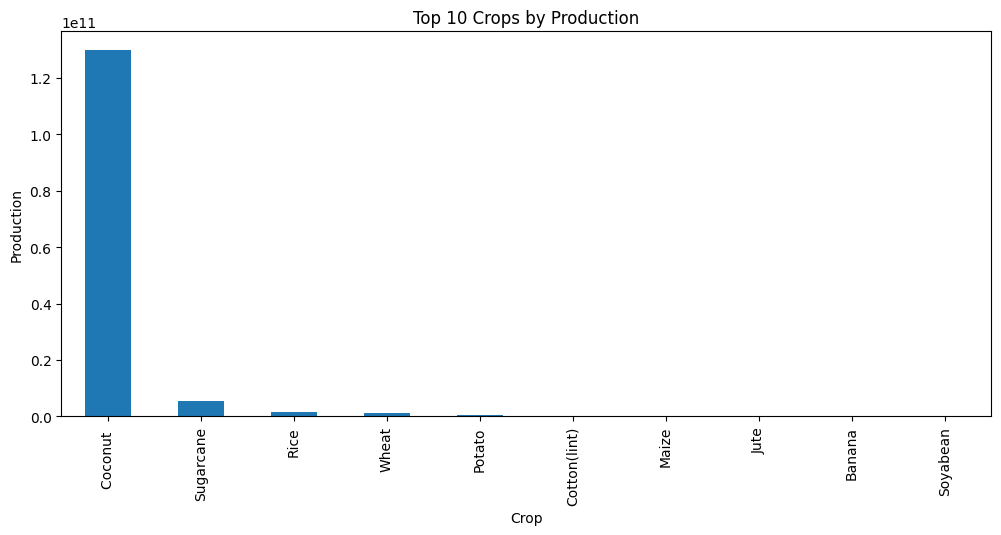

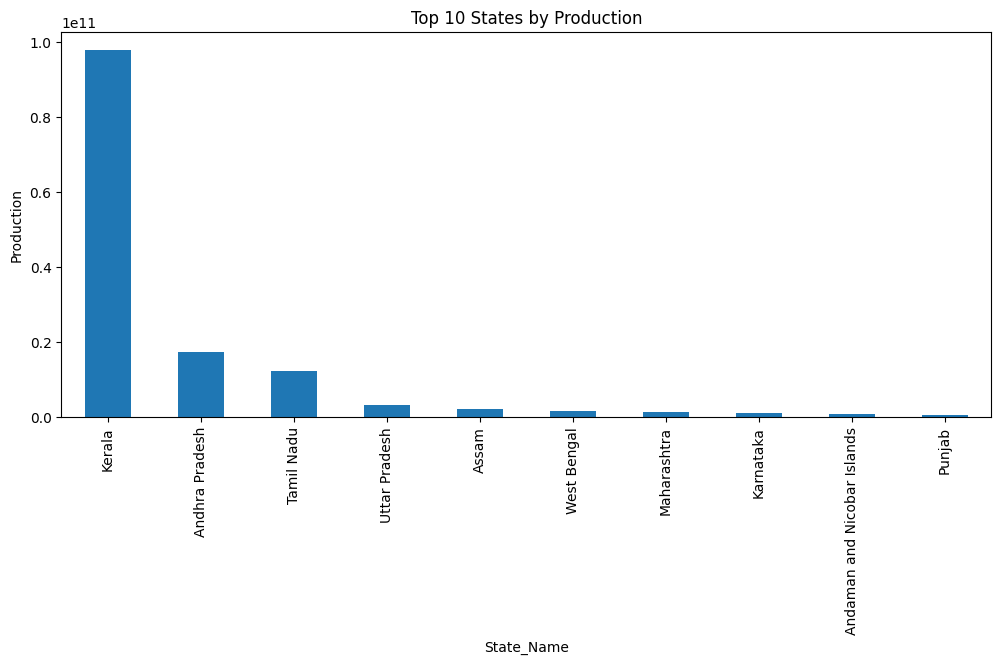

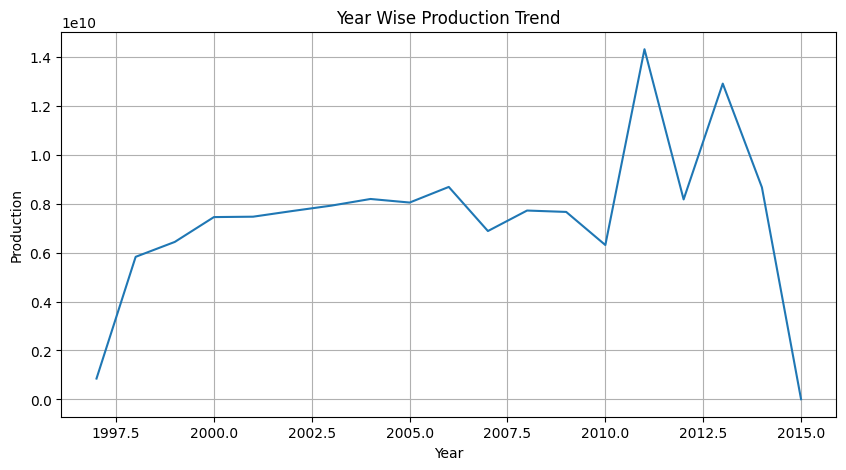

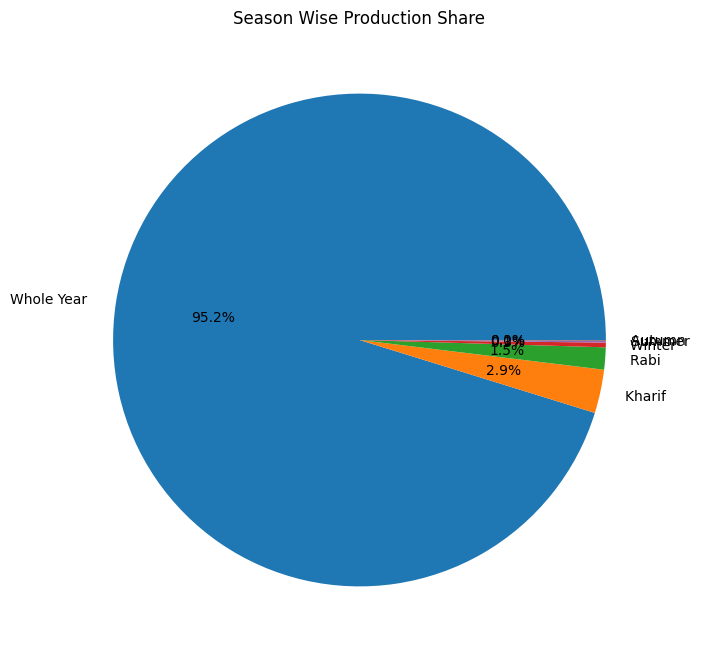

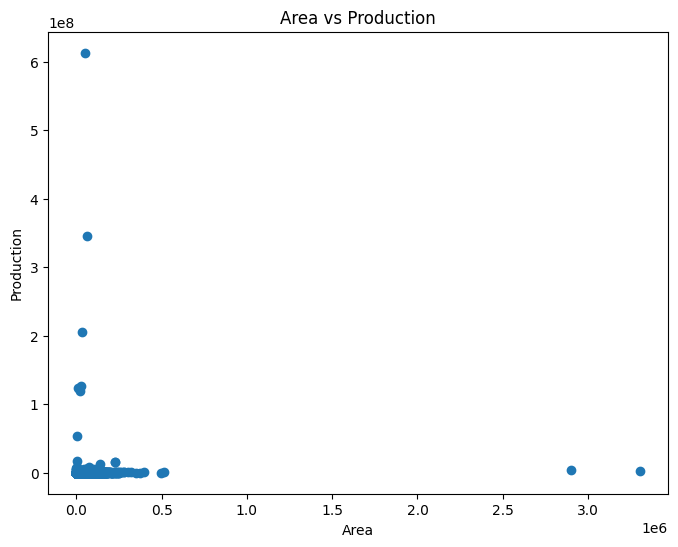


Report Saved Successfully


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('/content/crop_production 2.csv')

print("="*70)
print("CROP PRODUCTION DATASET ANALYSIS")
print("="*70)

print("\nDataset Shape:", df.shape)

print("\nColumns")
print(df.columns.tolist())

print("\nData Types")
print(df.dtypes)

print("\nMissing Values")
print(df.isnull().sum())

print("\nDuplicate Rows")
print(df.duplicated().sum())

print("\nNumerical Statistics")
print(df.describe())

print("\nUnique States:", df['State_Name'].nunique())
print("Unique Districts:", df['District_Name'].nunique())
print("Unique Crops:", df['Crop'].nunique())
print("Unique Seasons:", df['Season'].nunique())

top_crops = (
    df.groupby('Crop')['Production']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print("\nTop 10 Crops by Production")
print(top_crops)

top_states = (
    df.groupby('State_Name')['Production']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print("\nTop 10 States by Production")
print(top_states)

yield_df = (
    df.groupby('State_Name')
    .agg({
        'Area':'sum',
        'Production':'sum'
    })
)

yield_df['Yield'] = (
    yield_df['Production'] /
    yield_df['Area']
)

print("\nTop 10 States by Yield")
print(
    yield_df['Yield']
    .sort_values(ascending=False)
    .head(10)
)

season_prod = (
    df.groupby('Season')['Production']
    .sum()
    .sort_values(ascending=False)
)

print("\nSeason Wise Production")
print(season_prod)

yearly = (
    df.groupby('Crop_Year')['Production']
    .sum()
)

corr = df[['Area','Production']].corr()

print("\nCorrelation Matrix")
print(corr)

plt.figure(figsize=(12,5))
top_crops.plot(kind='bar')
plt.title("Top 10 Crops by Production")
plt.ylabel("Production")
plt.show()

plt.figure(figsize=(12,5))
top_states.plot(kind='bar')
plt.title("Top 10 States by Production")
plt.ylabel("Production")
plt.show()

plt.figure(figsize=(10,5))
plt.plot(yearly.index, yearly.values)
plt.title("Year Wise Production Trend")
plt.xlabel("Year")
plt.ylabel("Production")
plt.grid(True)
plt.show()

plt.figure(figsize=(8,8))
season_prod.plot(
    kind='pie',
    autopct='%1.1f%%'
)
plt.ylabel("")
plt.title("Season Wise Production Share")
plt.show()

sample = df.sample(
    min(5000, len(df)),
    random_state=42
)

plt.figure(figsize=(8,6))
plt.scatter(
    sample['Area'],
    sample['Production']
)
plt.xlabel("Area")
plt.ylabel("Production")
plt.title("Area vs Production")
plt.show()

with pd.ExcelWriter(
    "crop_analysis_report.xlsx"
) as writer:

    top_crops.to_excel(
        writer,
        sheet_name='Top Crops'
    )

    top_states.to_excel(
        writer,
        sheet_name='Top States'
    )

    yield_df.to_excel(
        writer,
        sheet_name='Yield Analysis'
    )

    season_prod.to_excel(
        writer,
        sheet_name='Season Analysis'
    )

print("\nReport Saved Successfully")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')